In [2]:
import json
import pandas as pd

path = '../../output/data.json'
a = json.load(open(path))

25518

/Users/sajeev/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  if __name__ == '__main__':
/Users/sajeev/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  if __name__ == '__main__':
/Users/sajeev/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may

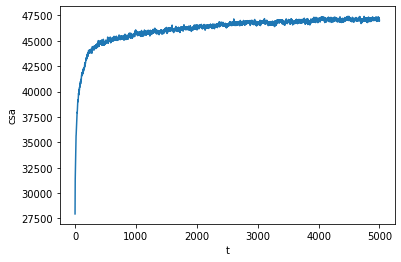

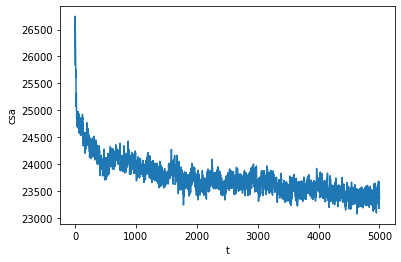

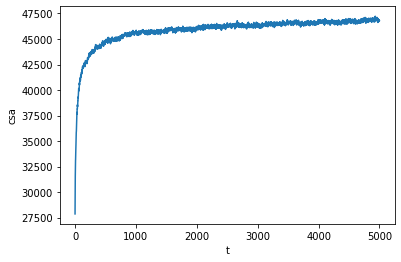

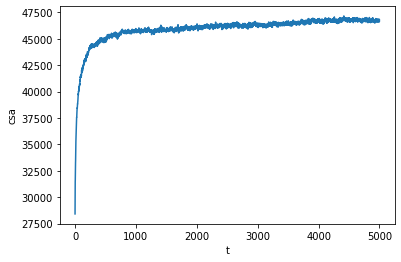

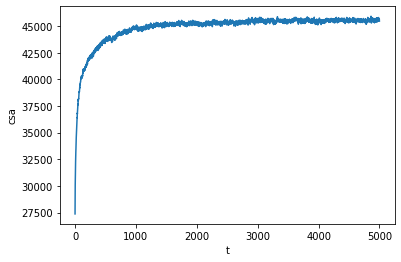

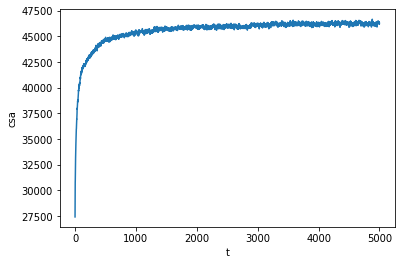

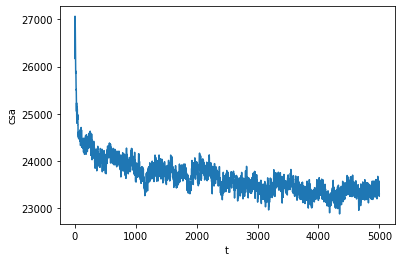

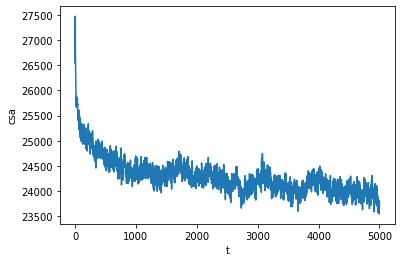

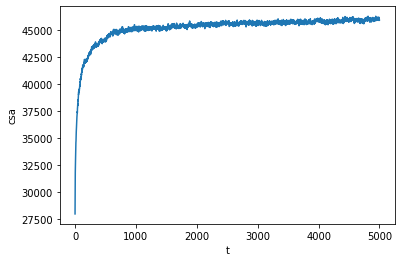

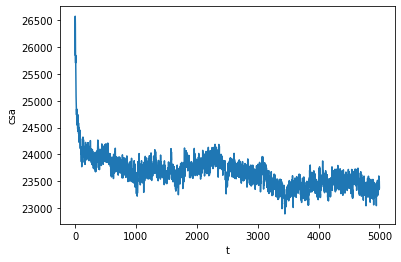

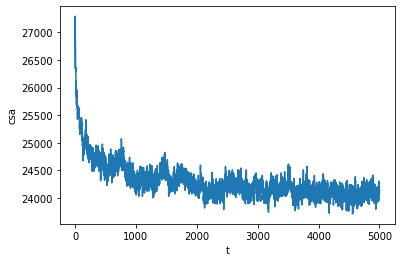

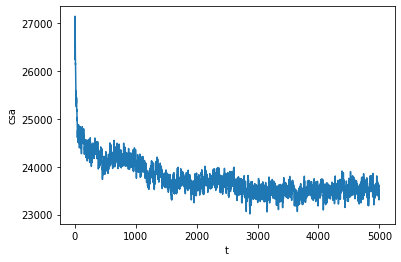

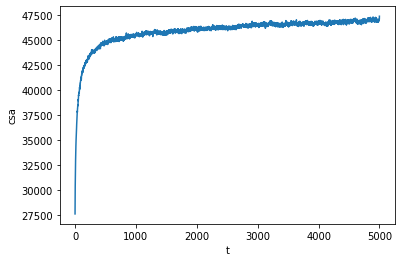

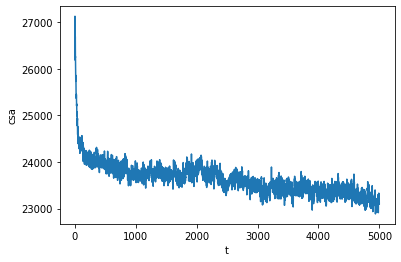

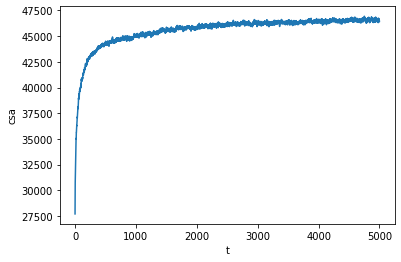

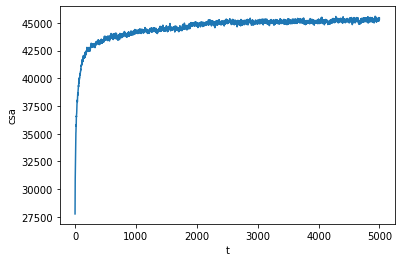

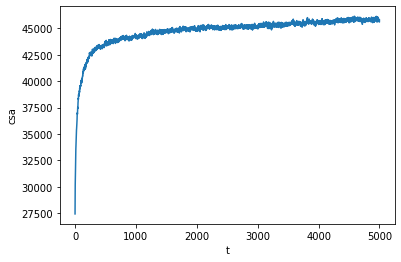

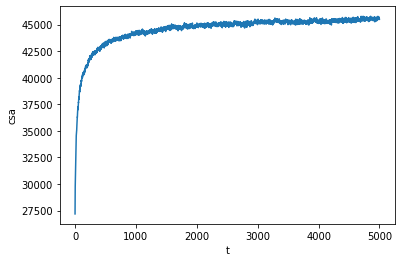

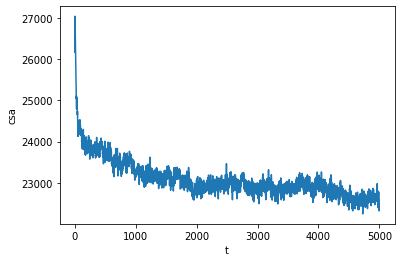

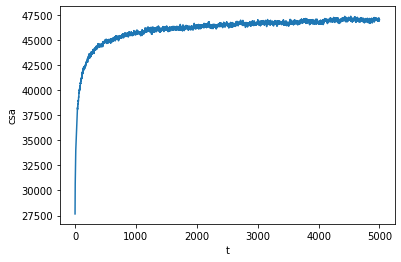

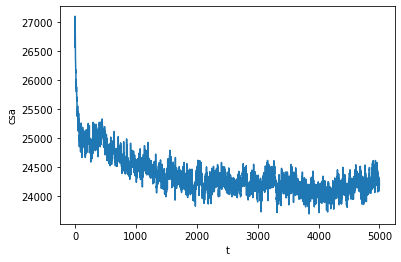

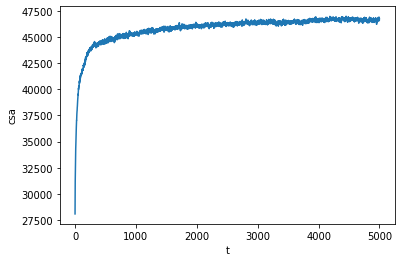

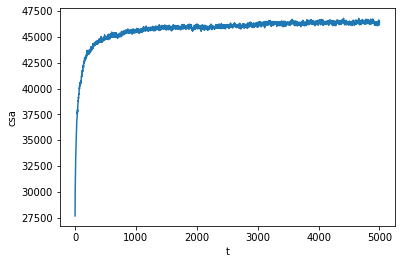

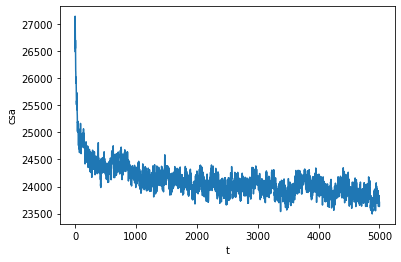

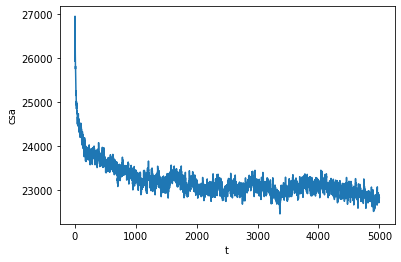

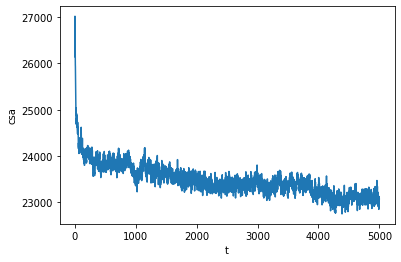

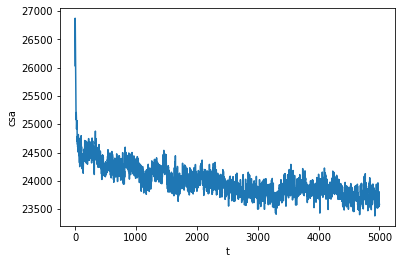

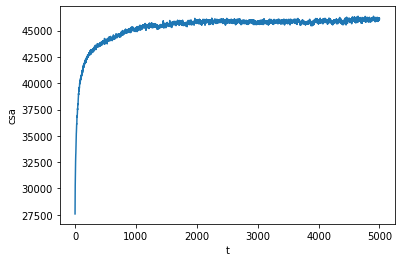

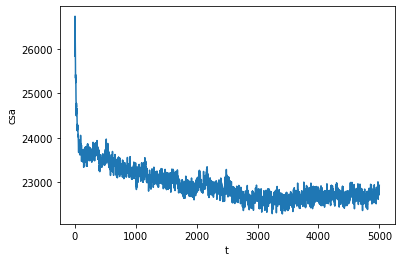

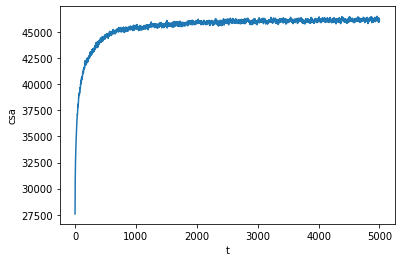

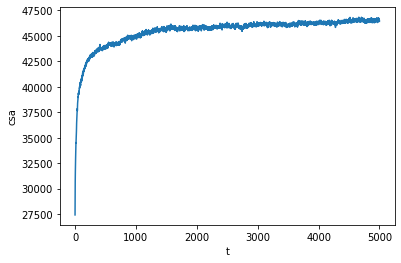

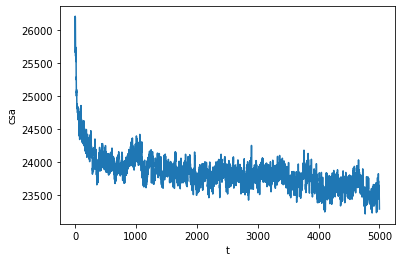

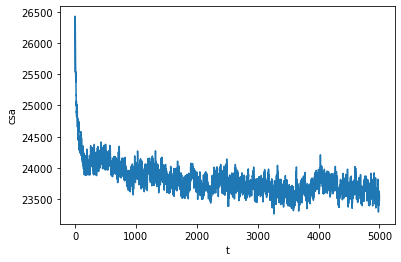

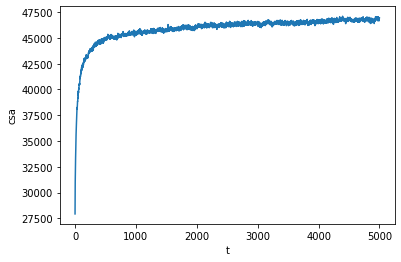

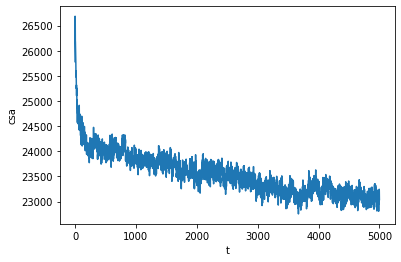

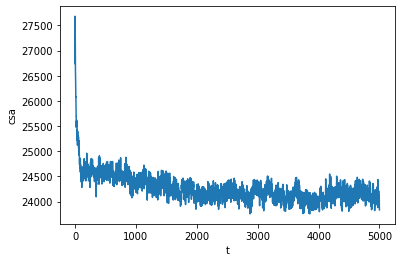

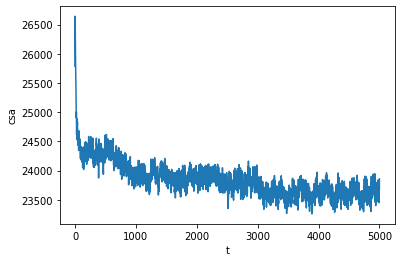

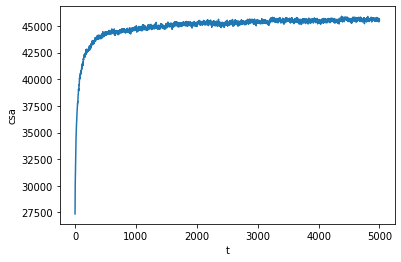

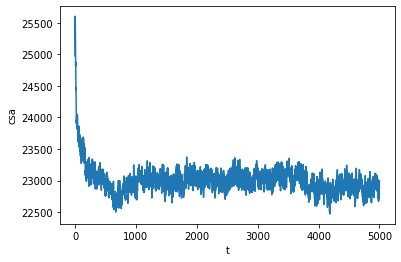

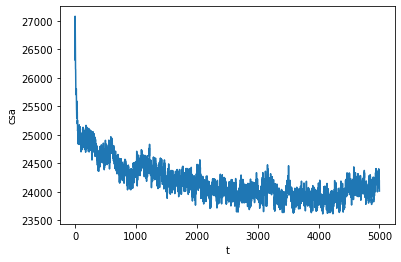

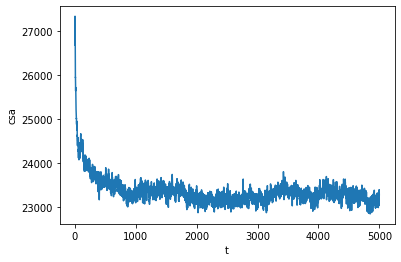

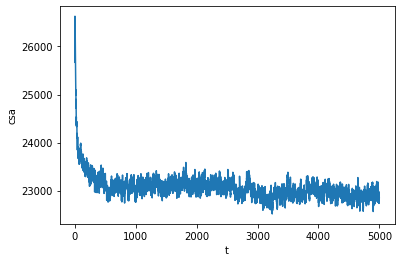

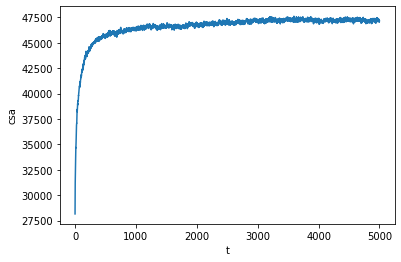

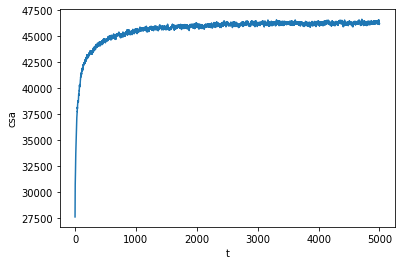

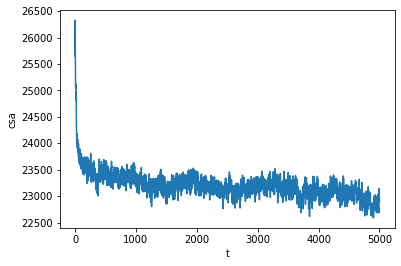

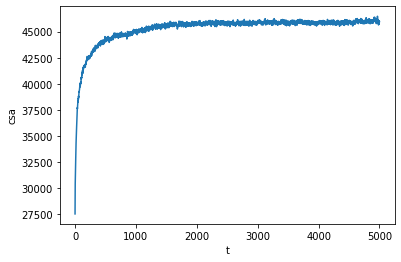

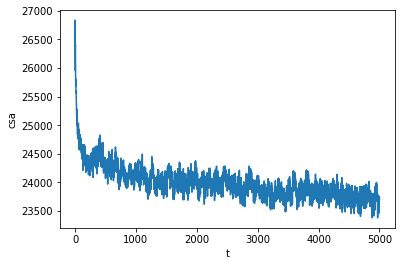

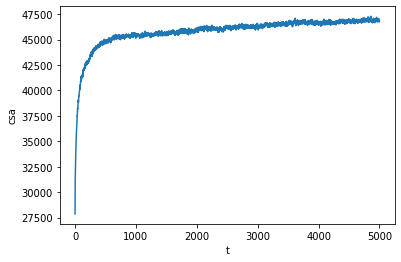

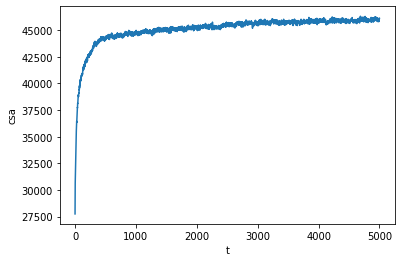

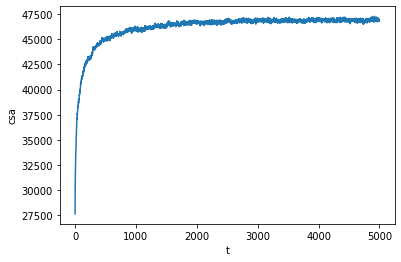

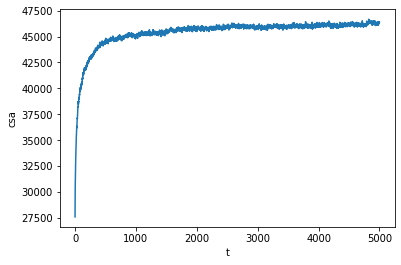

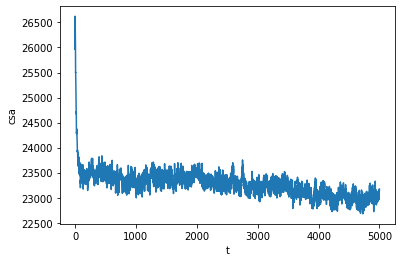

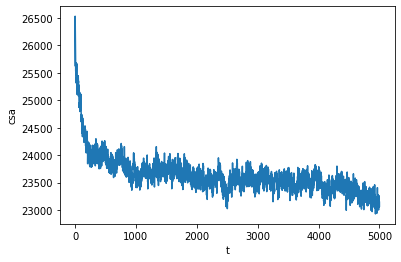

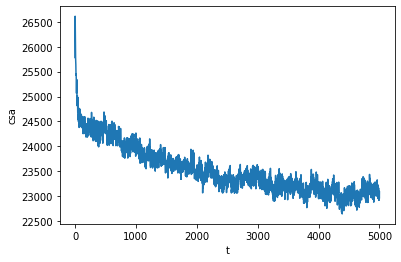

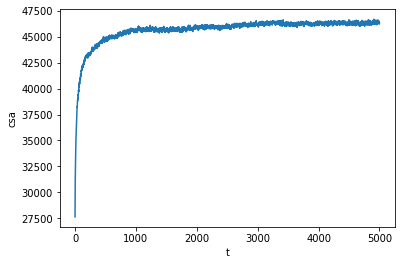

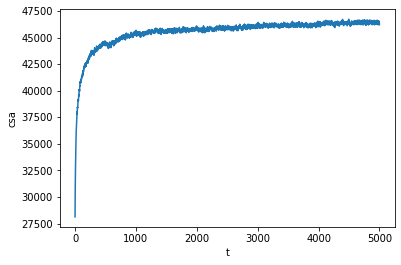

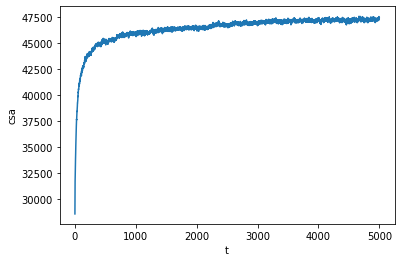

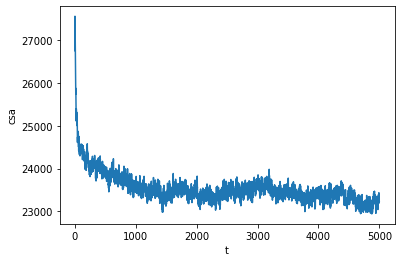

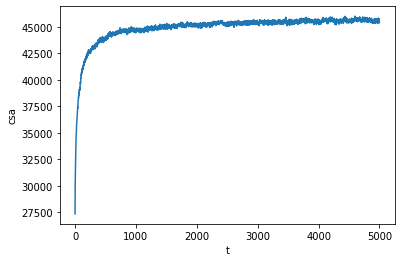

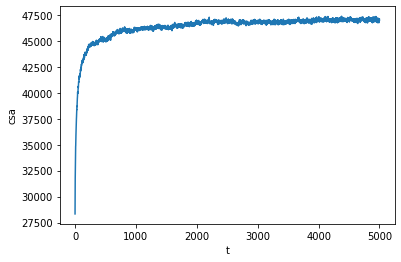

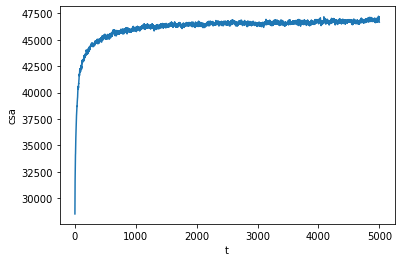

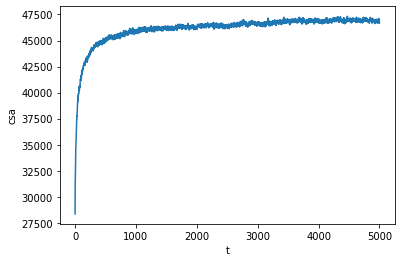

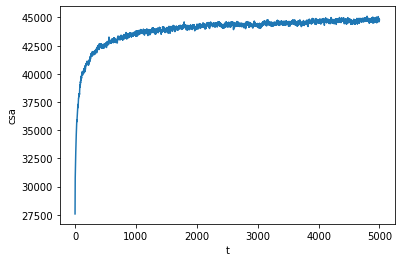

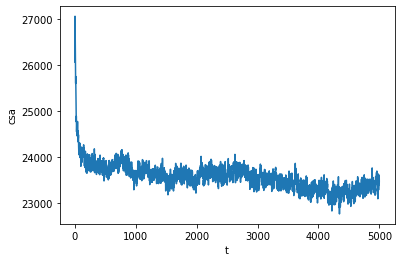

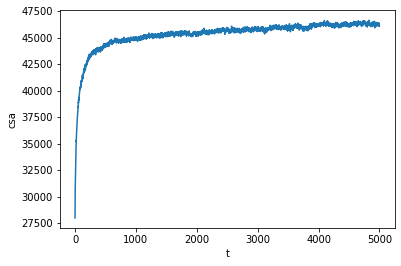

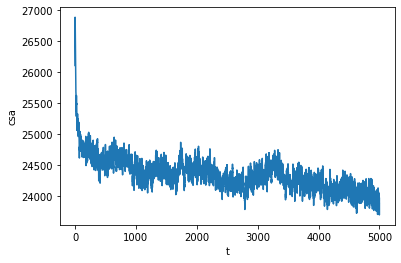

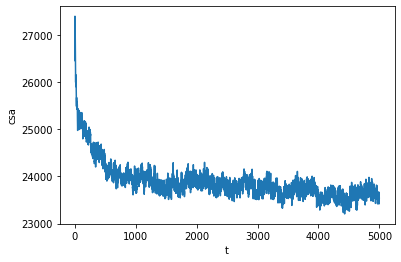

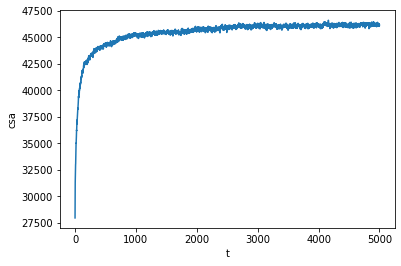

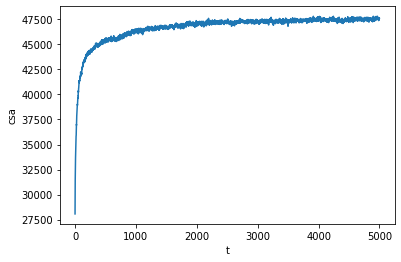

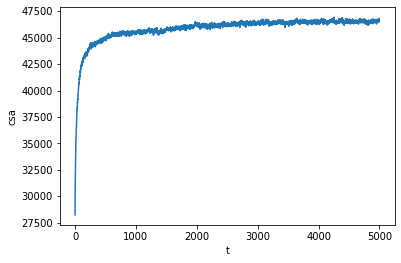

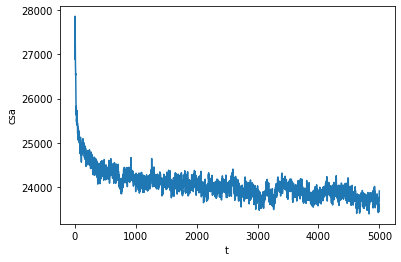

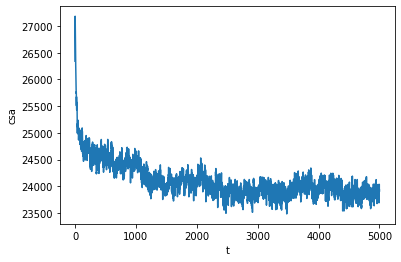

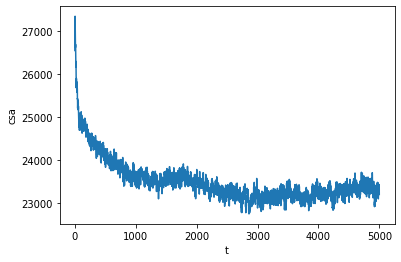

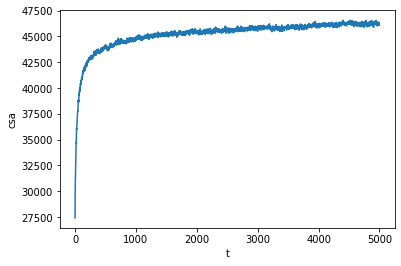

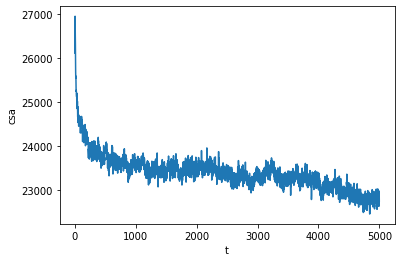

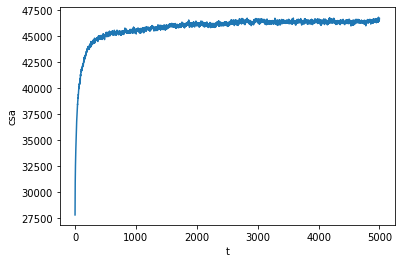

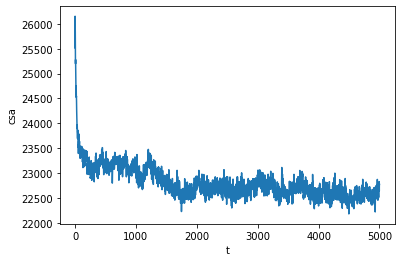

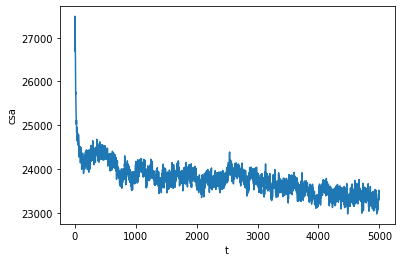

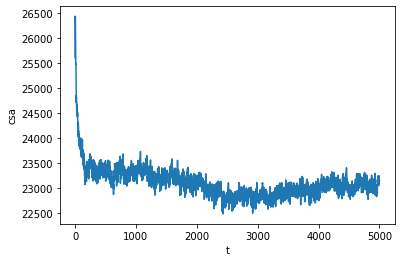

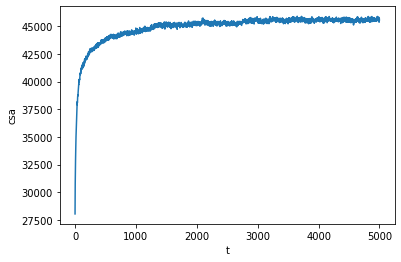

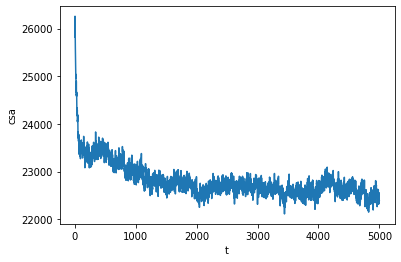

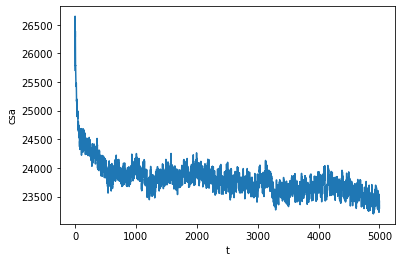

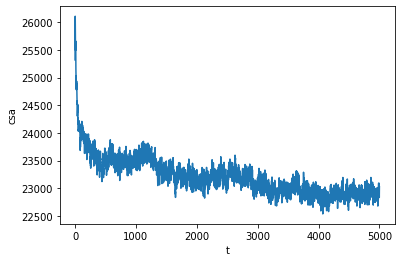

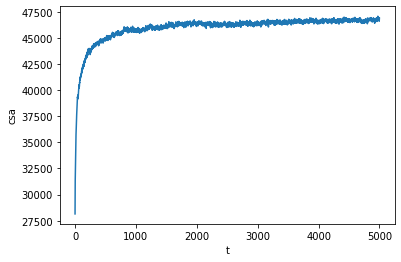

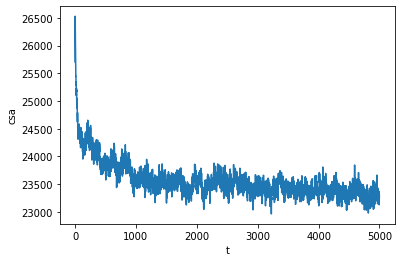

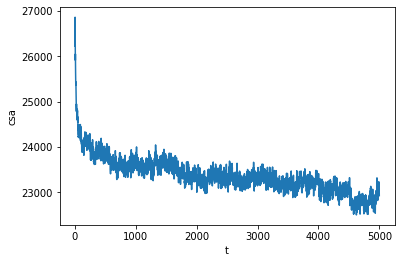

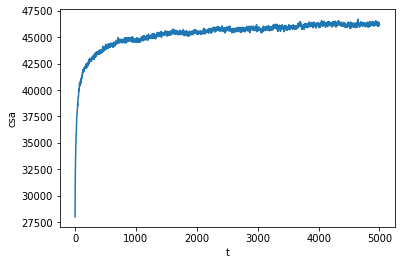

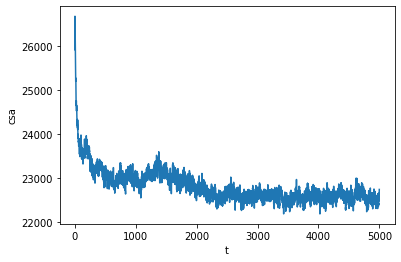

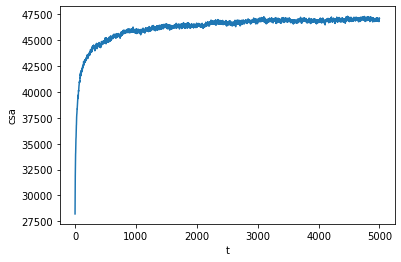

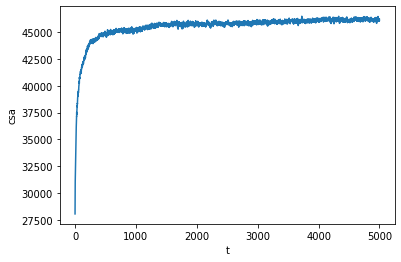

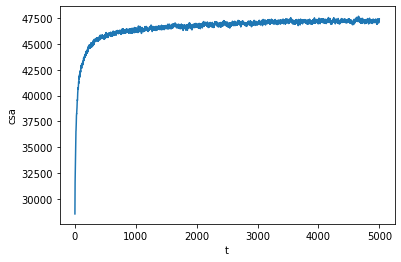

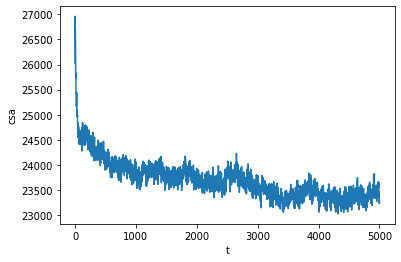

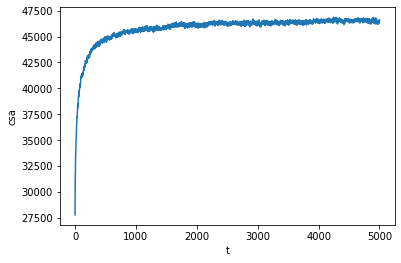

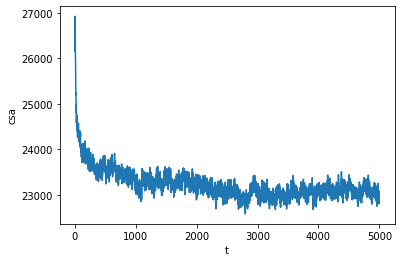

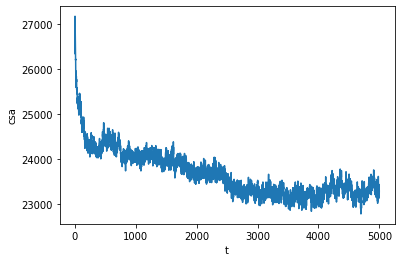

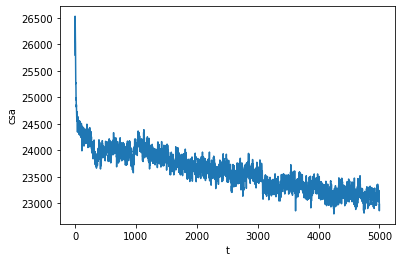

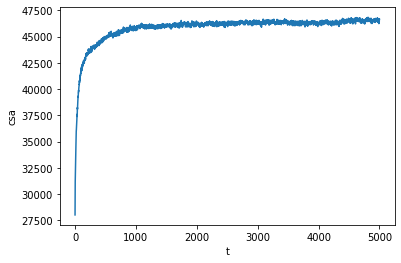

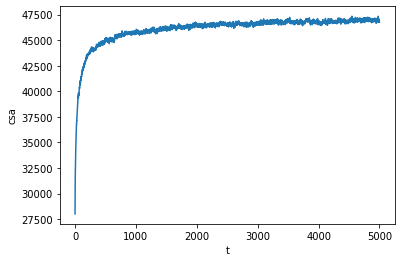

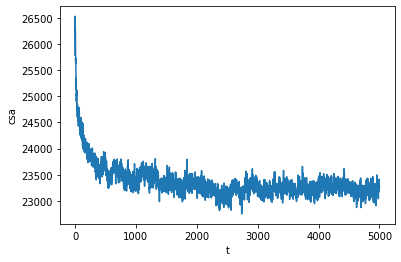

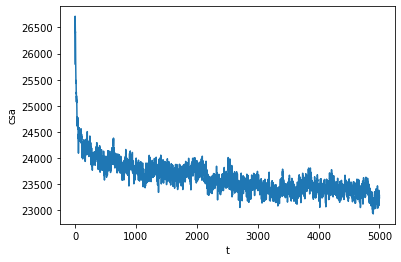

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


labels = {}

for d in sorted(a, key=lambda x: x['tag']):
    df = pd.DataFrame(data=d['result'], columns=['t', 'csa'])
    plt.figure()
    plot = sns.lineplot('t', 'csa', data=df)
    labels[d['tag']] = int(d['result'][-1][1] > d['result'][0][1])
    plot.get_figure().savefig(f"pics/sim_{d['tag']:02}.png")
    plt.close()

In [13]:
labels

{0: 1,
 1: 0,
 2: 1,
 3: 1,
 4: 1,
 5: 1,
 6: 0,
 7: 0,
 8: 1,
 9: 0,
 10: 0,
 11: 0,
 12: 1,
 13: 0,
 14: 1,
 15: 1,
 16: 1,
 17: 1,
 18: 0,
 19: 1,
 20: 0,
 21: 1,
 22: 1,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 1,
 28: 0,
 29: 1,
 30: 1,
 31: 0,
 32: 0,
 33: 1,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 0,
 40: 0,
 41: 0,
 42: 1,
 43: 1,
 44: 0,
 45: 1,
 46: 0,
 47: 1,
 48: 1,
 49: 1,
 50: 1,
 51: 0,
 52: 0,
 53: 0,
 54: 1,
 55: 1,
 56: 1,
 57: 0,
 58: 1,
 59: 1,
 60: 1,
 61: 1,
 62: 1,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 0,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 1,
 76: 0,
 77: 0,
 78: 0,
 79: 1,
 80: 0,
 81: 0,
 82: 0,
 83: 1,
 84: 0,
 85: 0,
 86: 1,
 87: 0,
 88: 1,
 89: 1,
 90: 1,
 91: 0,
 92: 1,
 93: 0,
 94: 0,
 95: 0,
 96: 1,
 97: 1,
 98: 0,
 99: 0}

In [24]:
import os
import sys
sys.path.append('..')
import tools
base = '../../output/gen_0'
for i, sim in enumerate(sorted(os.listdir(base))):
    tools.make_gif(path=os.path.join(base, sim, 'screenshots'), name=f'movies/sim_{i:02}.gif')

reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_00.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_01.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_02.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_03.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_04.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_05.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_06.gif ...
reading images ...
screenshots_0000.png screenshots_0100.png screenshots_0200.png
writing images to movies/sim_07.gif ...
reading images ...
scree

In [25]:
import os
import json
import pandas as pd

base = '../../stage'
rows = []
for sim in os.listdir(base):
    d = json.load(open(os.path.join(base, sim, 'Simulation', 'genome.json')))['signaling']
    sim_n = int(sim.split('_')[1])
    row = [sim_n, d['halfexpress'], d['sharpness'], labels[sim_n]]
    rows.append(row)
params = pd.DataFrame(rows, columns=['#', 'beta', 'epsilon', 'fitness'])

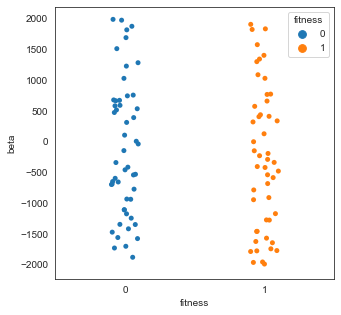

In [48]:
import numpy as np
import seaborn as sns

sns.set_style('white')
plt.figure(figsize=(5,5))
plot_ = sns.stripplot('fitness', 'beta', hue='fitness', data=params)
plot_.get_figure().savefig('pics/_distribution.png', dpi=600)

In [24]:
params.set_index('#').sort_index().to_csv('params.csv')